In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import random
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.regularizers import l2

In [8]:
# ==========================================
# SET RANDOM SEED (For Reproducibility)
# ==========================================
SEED_VALUE = 42

# 1. Set Python's built-in random seed
os.environ['PYTHONHASHSEED'] = str(SEED_VALUE)
random.seed(SEED_VALUE)

# 2. Set NumPy's random seed
np.random.seed(SEED_VALUE)

# 3. Set TensorFlow's random seed
tf.random.set_seed(SEED_VALUE)

print(f"Random Seed set to: {SEED_VALUE}")

Random Seed set to: 42


In [9]:
# ==========================================
# 1. SETUP PATHS
# ==========================================
# Input 1: The Visual Features (4 quarters * 4096 dims)
path_dynamic = "dynamic_features_per_quarter.csv"

# Input 2: The Infrastructure Features (Roads, POIs)
path_static = "static_osm_features_sample50.csv"

# Target: The DHS Wealth Index Data
# You need a CSV with 'DHSCLUST' and 'HV270' (Wealth Index) or 'WEALTH_INDEX'
path_dhs = "dhs_wealth_sample50.csv"

In [10]:
# ==========================================
# 2. LOAD & MERGE DATA
# ==========================================
print("Loading datasets...")
df_dyn = pd.read_csv(path_dynamic)
df_stat = pd.read_csv(path_static)
df_target = pd.read_csv(path_dhs)



# Ensure Cluster IDs are integers for merging
df_dyn['ClusterID'] = df_dyn['ClusterID'].astype(int)
df_stat['DHSCLUST'] = df_stat['DHSCLUST'].astype(int)
df_target['DHSCLUST'] = df_target['DHSCLUST'].astype(int)

# A. Prepare Dynamic Data (Reshape for LSTM)
# We need shape: (Num_Clusters, 4_TimeSteps, 4096_Features)
print("Reshaping Dynamic Features...")
unique_clusters = df_dyn['ClusterID'].unique()
X_dynamic = []
valid_clusters = []



Loading datasets...
Reshaping Dynamic Features...


In [11]:
for c_id in unique_clusters:
    # Get all 4 quarters for this cluster
    subset = df_dyn[df_dyn['ClusterID'] == c_id].sort_values('Quarter')
    
    # Only keep if we have exactly 4 quarters
    if len(subset) == 4:
        # Drop ID and Quarter columns, keep only features
        feats = subset.drop(columns=['ClusterID', 'Quarter']).values
        X_dynamic.append(feats)
        valid_clusters.append(c_id)

X_dynamic = np.array(X_dynamic) # Shape: (N, 4, 4096)
print(f"Dynamic Input Shape: {X_dynamic.shape}")

# B. Align Static Data & Targets
# We only want clusters that exist in our valid_clusters list
df_stat = df_stat[df_stat['DHSCLUST'].isin(valid_clusters)].set_index('DHSCLUST')
df_target = df_target[df_target['DHSCLUST'].isin(valid_clusters)].set_index('DHSCLUST')

# Reindex to match the order of X_dynamic exactly
df_stat = df_stat.reindex(valid_clusters)
df_target = df_target.reindex(valid_clusters)

# Check for NaNs (Missing targets)
if df_target['Wealth_Index'].isna().any():
    print("Warning: Some clusters are missing Wealth Index targets. Dropping them.")
    # (Add drop logic here if needed, but usually DHS is complete)

X_static = df_stat.values # Shape: (N, Num_OSM_Features)
y = df_target['Wealth_Index'].values # Shape: (N,)

Dynamic Input Shape: (50, 4, 4096)


In [12]:
# ==========================================
# 3. SPLIT & SCALE
# ==========================================
# Split into Train/Test
X_dyn_train, X_dyn_test, X_stat_train, X_stat_test, y_train, y_test = train_test_split(
    X_dynamic, X_static, y, test_size=0.2, random_state=SEED_VALUE
)

# Normalize Static Features
scaler = StandardScaler()
X_stat_train = scaler.fit_transform(X_stat_train)
X_stat_test = scaler.transform(X_stat_test)

print(f"Training Samples: {len(y_train)}")
print(f"Test Samples: {len(y_test)}")

Training Samples: 40
Test Samples: 10


In [13]:
# ==========================================
# 4. DEFINE HYBRID MODEL
# ==========================================
# Branch 1: LSTM for Visual/Temporal
input_dynamic = Input(shape=(4, 4096), name="Dynamic_Input")
x1 = LSTM(16, return_sequences=False, kernel_regularizer=l2(1e-4))(input_dynamic) # 64-unit memory
x1 = Dropout(0.5)(x1)

# Branch 2: Dense for Static/Infrastructure
input_static = Input(shape=(X_static.shape[1],), name="Static_Input")
x2 = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(input_static)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)

# Fusion: Combine the two brains
combined = Concatenate()([x1, x2])

# Interpretation Layers
z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(combined)
z = Dropout(0.3)(z)
output = Dense(1, activation='linear', name="Wealth_Prediction")(z) # Linear for Regression

model = Model(inputs=[input_dynamic, input_static], outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Static_Input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dynamic_Input       │ (None, 4, 4096)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        336 │ Static_Input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16)        │    263,232 │ Dynamic_Input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wealth_Prediction   │ (None, 1)         │         17 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 264,177 (1.01 MB)

 Trainable params: 264,145 (1.01 MB)

 Non-trainable params: 32 (128.00 B)

In [14]:
# ==========================================
# 5. TRAIN
# ==========================================
print("Starting Training...")
history = model.fit(
    x=[X_dyn_train, X_stat_train], # Two inputs!
    y=y_train,
    validation_data=([X_dyn_test, X_stat_test], y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Starting Training...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 1.0341 - mae: 0.7815 - val_loss: 0.5402 - val_mae: 0.5858
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8816 - mae: 0.7352 - val_loss: 0.5489 - val_mae: 0.5882
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5136 - mae: 0.5998 - val_loss: 0.5456 - val_mae: 0.5854
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0266 - mae: 0.7701 - val_loss: 0.5436 - val_mae: 0.5810
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8293 - mae: 0.7186 - val_loss: 0.5428 - val_mae: 0.5813
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5278 - mae: 0.5467 - val_loss: 0.5451 - val_mae: 0.5833
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5902 - mae: 0.6114 - val_loss: 0.5454 - val_mae: 0.5828
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6689 - mae: 0.6696 - val_loss: 0.5392 - val_mae: 0.5775
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.

In [15]:
# ==========================================
# 6. EVALUATE
# ==========================================


print("\nEvaluating...")
predictions = model.predict([X_dyn_test, X_stat_test])
r2 = r2_score(y_test, predictions)

print("-" * 30)
print(f"FINAL R² SCORE: {r2:.4f}")
print("-" * 30)

# Save the model for Phase 5 (Visualization)
model.save("final_hybrid_poverty_model.h5")
print("Model saved as 'final_hybrid_poverty_model.h5'")


Evaluating...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


------------------------------
FINAL R² SCORE: 0.0192
------------------------------
Model saved as 'final_hybrid_poverty_model.h5'


Predicting on Test Set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R² Score: 0.0192


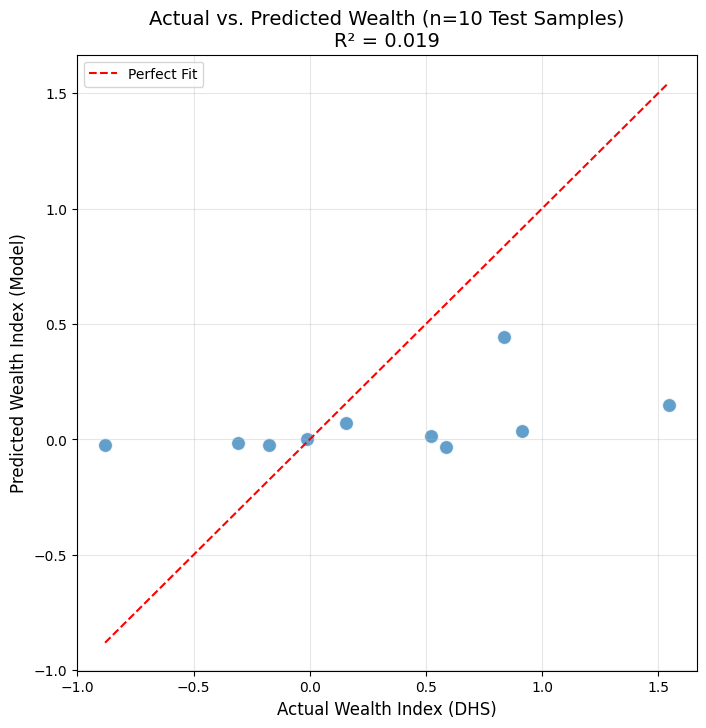

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# ==========================================
# 1. GENERATE PREDICTIONS
# ==========================================
# Use the model and data from your active session
print("Predicting on Test Set...")
predictions = model.predict([X_dyn_test, X_stat_test])

# Flatten to 1D array
y_pred = predictions.flatten()
y_true = y_test

# ==========================================
# 2. CALCULATE METRICS
# ==========================================
r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}") 
# Note: On 50 samples, R² might be low (or even negative). 
# Don't panic. If it's > 0.3 on this small sample, that's amazing.

# ==========================================
# 3. PLOT SCATTER
# ==========================================
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.7, s=100)

# Add "Perfect Prediction" line (y=x)
min_val = min(min(y_true), min(y_pred))
max_val = max(max(y_true), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title(f"Actual vs. Predicted Wealth (n={len(y_true)} Test Samples)\nR² = {r2:.3f}", fontsize=14)
plt.xlabel("Actual Wealth Index (DHS)", fontsize=12)
plt.ylabel("Predicted Wealth Index (Model)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()